In [11]:
import os
import gc
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision.io import read_image
from torchvision import models
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, SubsetRandomSampler
from safetensors.torch import save_model, load_model
import torchvision.transforms.functional as F

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [13]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')

def image_transform(test=False):
    # normalize = transforms.Normalize(
    #     mean=[0.4914, 0.4822, 0.4465],
    #     std=[0.2023, 0.1994, 0.2010],
    # )
    mid_transforms = [
    ] if test else [
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomVerticalFlip(),
        #transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
        #transforms.ColorJitter(),
        # transforms.GaussianBlur(5),
    ]
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
    ] + mid_transforms + [
        transforms.Resize((224,224)),
        # normalize,
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])


def load_image(path):
    transform = image_transform(test=True)
    image = read_image(path)
    image = transform(image)
    return image

In [14]:
def load_paths(root_dir, list_path=None) -> list:
    if list_path is None:
        filenames = next(os.walk(root_dir), (None, None, []))[2]
        return [os.path.join(root_dir, filename) for filename in filenames]
    else:
        filenames = pd.read_csv(list_path, header=None, index_col=None)
        return [os.path.join(root_dir, filename) for _, row in filenames.items() for filename in row ]

In [15]:
images_path = '../data/logos'

In [16]:
max_width = 0
max_height = 0
min_width = 1000
min_height = 1000
for path in load_paths(images_path)[:5]:
    image = read_image(path)
    assert image.size()[0] == 3
    width, height = image.size()[1], image.size()[2]
    max_width = max(max_width, width)
    max_height = max(max_height, height)
    min_width = min(min_width, width)
    min_height = min(min_height, height)
print(f'Min size: {min_width}x{min_height}')
print(f'Max size: {max_width}x{max_height}')

Min size: 337x912
Max size: 945x945


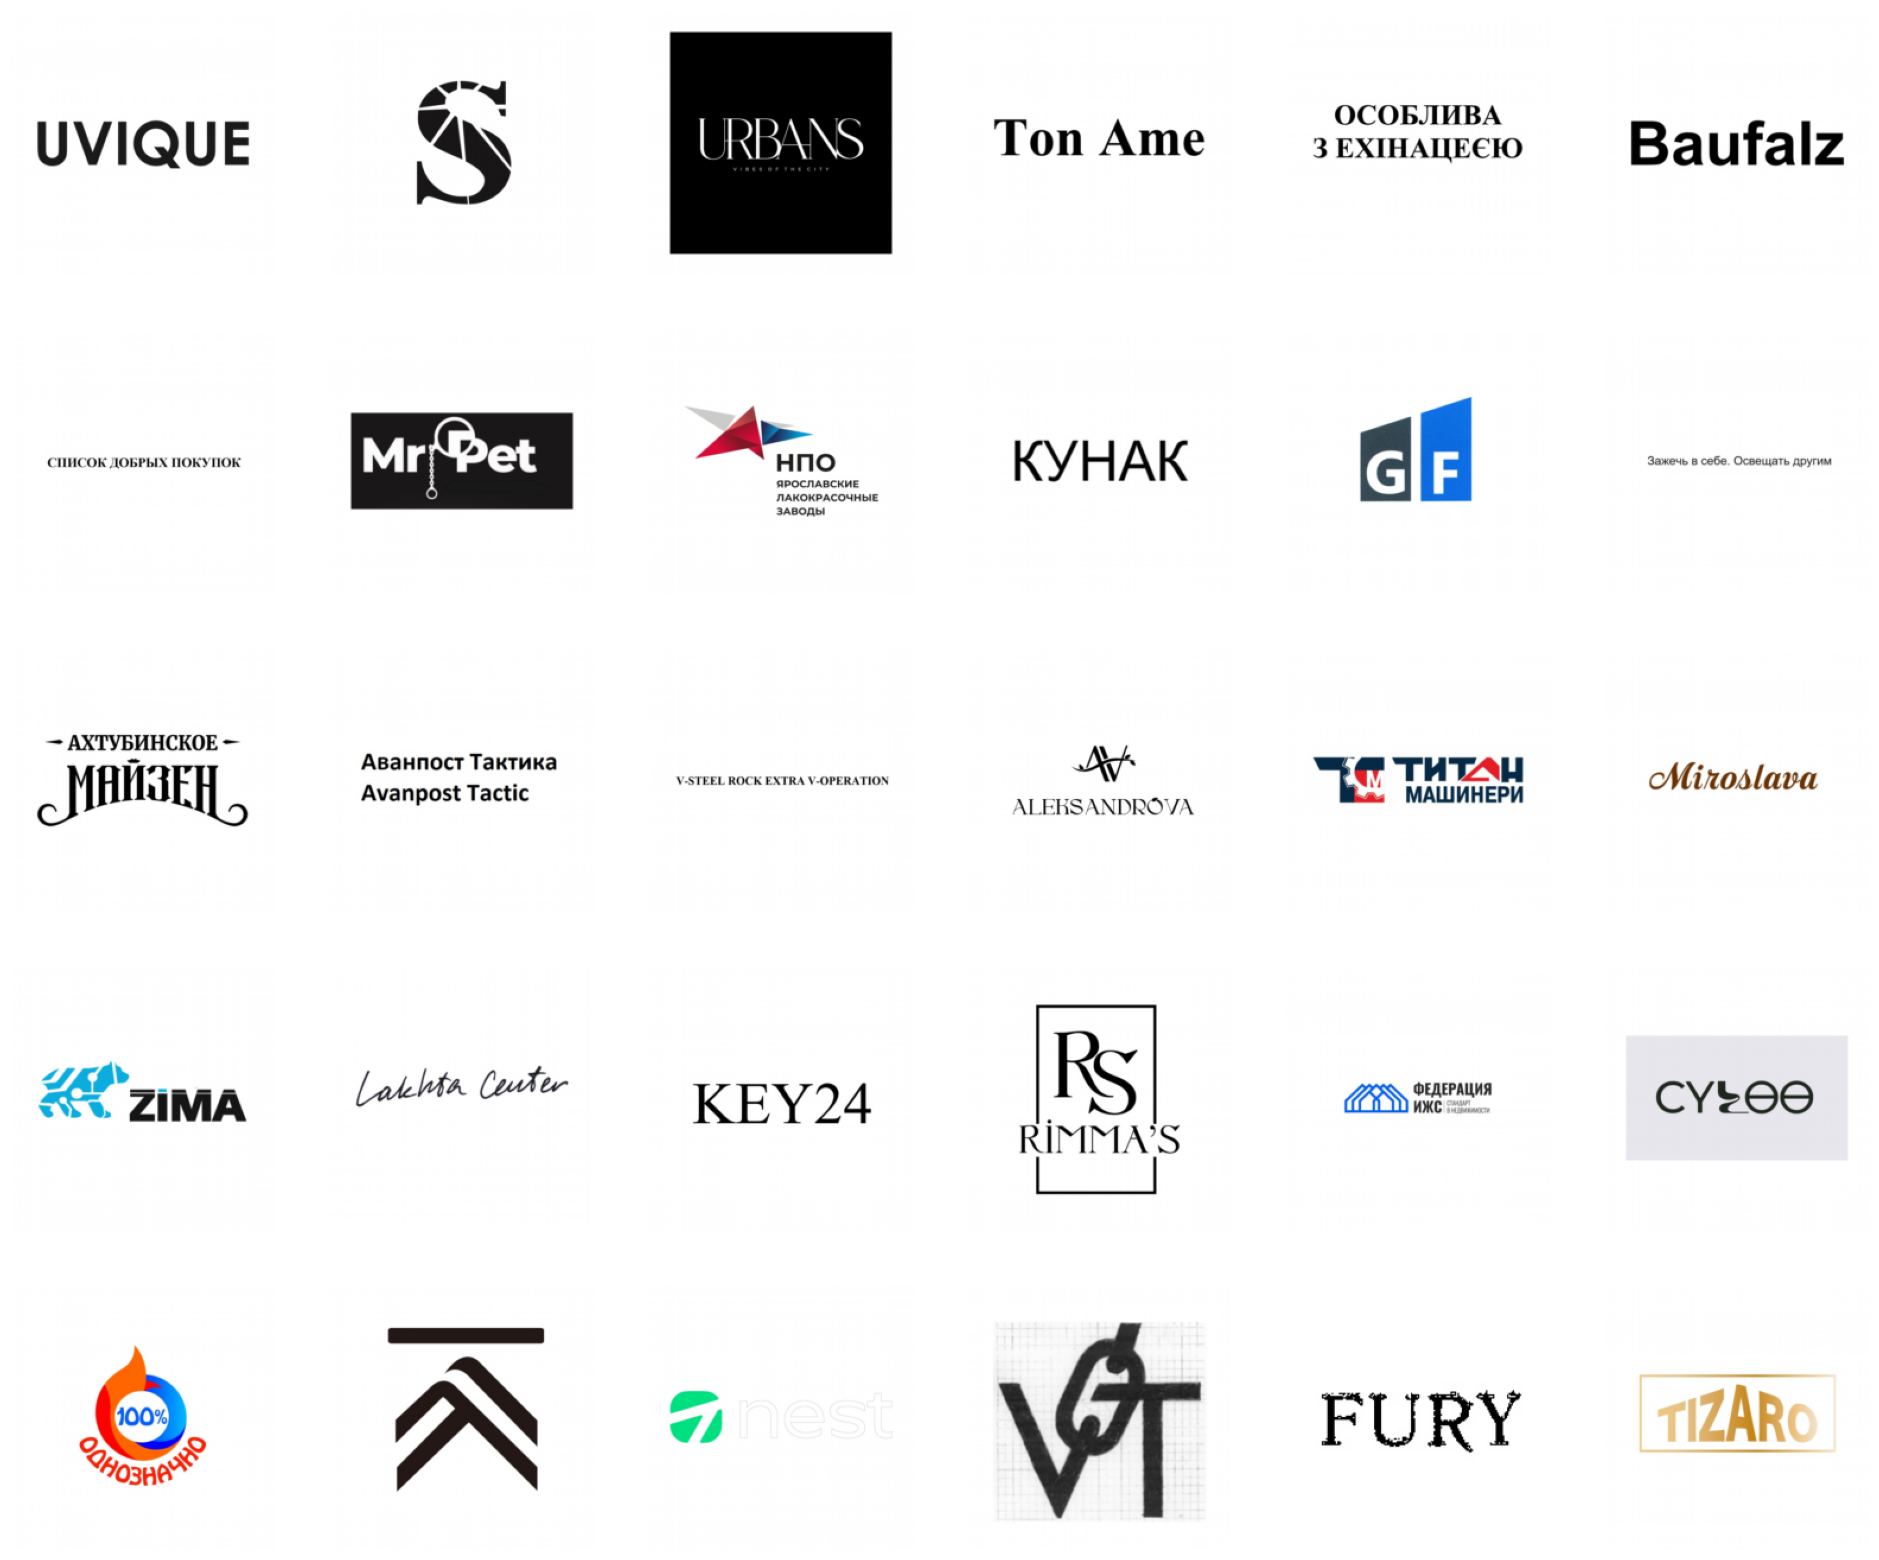

In [17]:
w, h = 6, 5
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

for i, (img_path, ax) in enumerate(zip(image_paths, axs.flatten())):
    img = load_image(img_path)
    #prediction = model(img.unsqueeze(0).to(device)).item()

    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_axis_off()
    #ax.set_title(f'Labelled: {label:.0f}, Predicted: {prediction:.0f}')

plt.show()

In [18]:
class LogosDataset(Dataset):
    def __init__(self, root_dir, list_path, frames_limit=None, transform=None):
        self.root = root_dir
        self.transform = transform

        self.images = []

        images = load_paths(root_dir, list_path)
        image_paths = []

        if frames_limit is None:
            image_paths = images
        else:
            np.random.shuffle(images)
            image_paths.extend(images[:frames_limit])

        self.images.extend(image_paths)

        print(f'loaded {len(self.images)} paths')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        return image, img_path

In [19]:
def data_loader(data_dir, list_path, batch_size, frames_limit=None, shuffle=True, test=False):
    transform = image_transform(test)
    dataset = LogosDataset(data_dir, list_path, frames_limit, transform)

    indices = list(range(len(dataset)))
    if shuffle:
        np.random.shuffle(indices)

    sampler = SubsetRandomSampler(indices)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    return loader

In [20]:
#loader_test = data_loader('../data/logos', 16, frames_limit=1000, test=True)
loader_train = data_loader('../data/logos', '../data/similar_train.csv', 16)
loader_valid = data_loader('../data/logos', '../data/similar_valid.csv', 16, test=True)
loader_all = data_loader('../data/logos', None, 64, frames_limit=1000, test=True)

loaded 25 paths
loaded 7 paths
loaded 1000 paths


In [21]:
#model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT).to(device)
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT).to(device)
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier[6].parameters():
    param.requires_grad = True
model.eval()
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [22]:
def generate_embeddings(model):
    model = model.to(device)
    embeddings = torch.tensor([]).to(device)
    all_paths = []
    for images, paths in tqdm(loader_all):
        encoding = model(images.to(device)).detach()
        embeddings = torch.cat((embeddings, encoding))
        all_paths += paths
    return embeddings, all_paths

In [23]:
image_embeddings, image_embedding_paths = generate_embeddings(model)
image_embeddings

  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:04<00:00,  3.55it/s]


tensor([[-1.4465, -0.0769, -2.5384,  ..., -1.8207,  0.1526,  0.6019],
        [-1.3709,  0.2483, -2.5946,  ..., -1.7486,  0.2102,  0.6782],
        [-3.0231, -0.8374, -3.7319,  ..., -0.0790,  0.2089,  2.7395],
        ...,
        [-1.5348, -0.1488, -2.8581,  ..., -1.4564,  0.4700,  0.6016],
        [-2.8253, -1.1305, -2.7686,  ...,  0.4165,  0.2847,  3.1113],
        [-2.1111, -2.5526, -3.5048,  ...,  0.0653, -0.8923,  2.3005]],
       device='cuda:0')

In [24]:
def compute_similarity(image_path, embeddings, model):
    image = load_image(image_path)
    encoded = model.to(device)(image.unsqueeze(0).to(device)).detach()

    similarity_fn = nn.CosineSimilarity()
    def similarity(other_enc):
        return similarity_fn(encoded, other_enc)
    similarity_vec = torch.vmap(similarity)
    return similarity_vec(embeddings)

In [25]:
compute_similarity(image_embedding_paths[0], image_embeddings, model)

tensor([[1.0000],
        [0.9895],
        [0.8115],
        [0.8997],
        [0.7496],
        [0.9865],
        [0.8312],
        [0.9746],
        [0.8733],
        [0.9953],
        [0.9783],
        [0.9747],
        [0.9307],
        [0.9815],
        [0.9624],
        [0.9766],
        [0.9858],
        [0.9338],
        [0.9498],
        [0.7243],
        [0.9875],
        [0.5807],
        [0.7499],
        [0.7821],
        [0.9661],
        [0.8289],
        [0.5230],
        [0.8518],
        [0.9833],
        [0.9710],
        [0.8995],
        [0.9255],
        [0.5663],
        [0.5861],
        [0.6542],
        [0.9793],
        [0.7474],
        [0.7184],
        [0.9609],
        [0.9829],
        [0.9720],
        [0.9907],
        [0.9668],
        [0.9621],
        [0.6931],
        [0.7784],
        [0.7200],
        [0.8638],
        [0.8092],
        [0.9862],
        [0.6292],
        [0.9412],
        [0.9857],
        [0.9758],
        [0.9627],
        [0

10it [00:00, 25.37it/s]


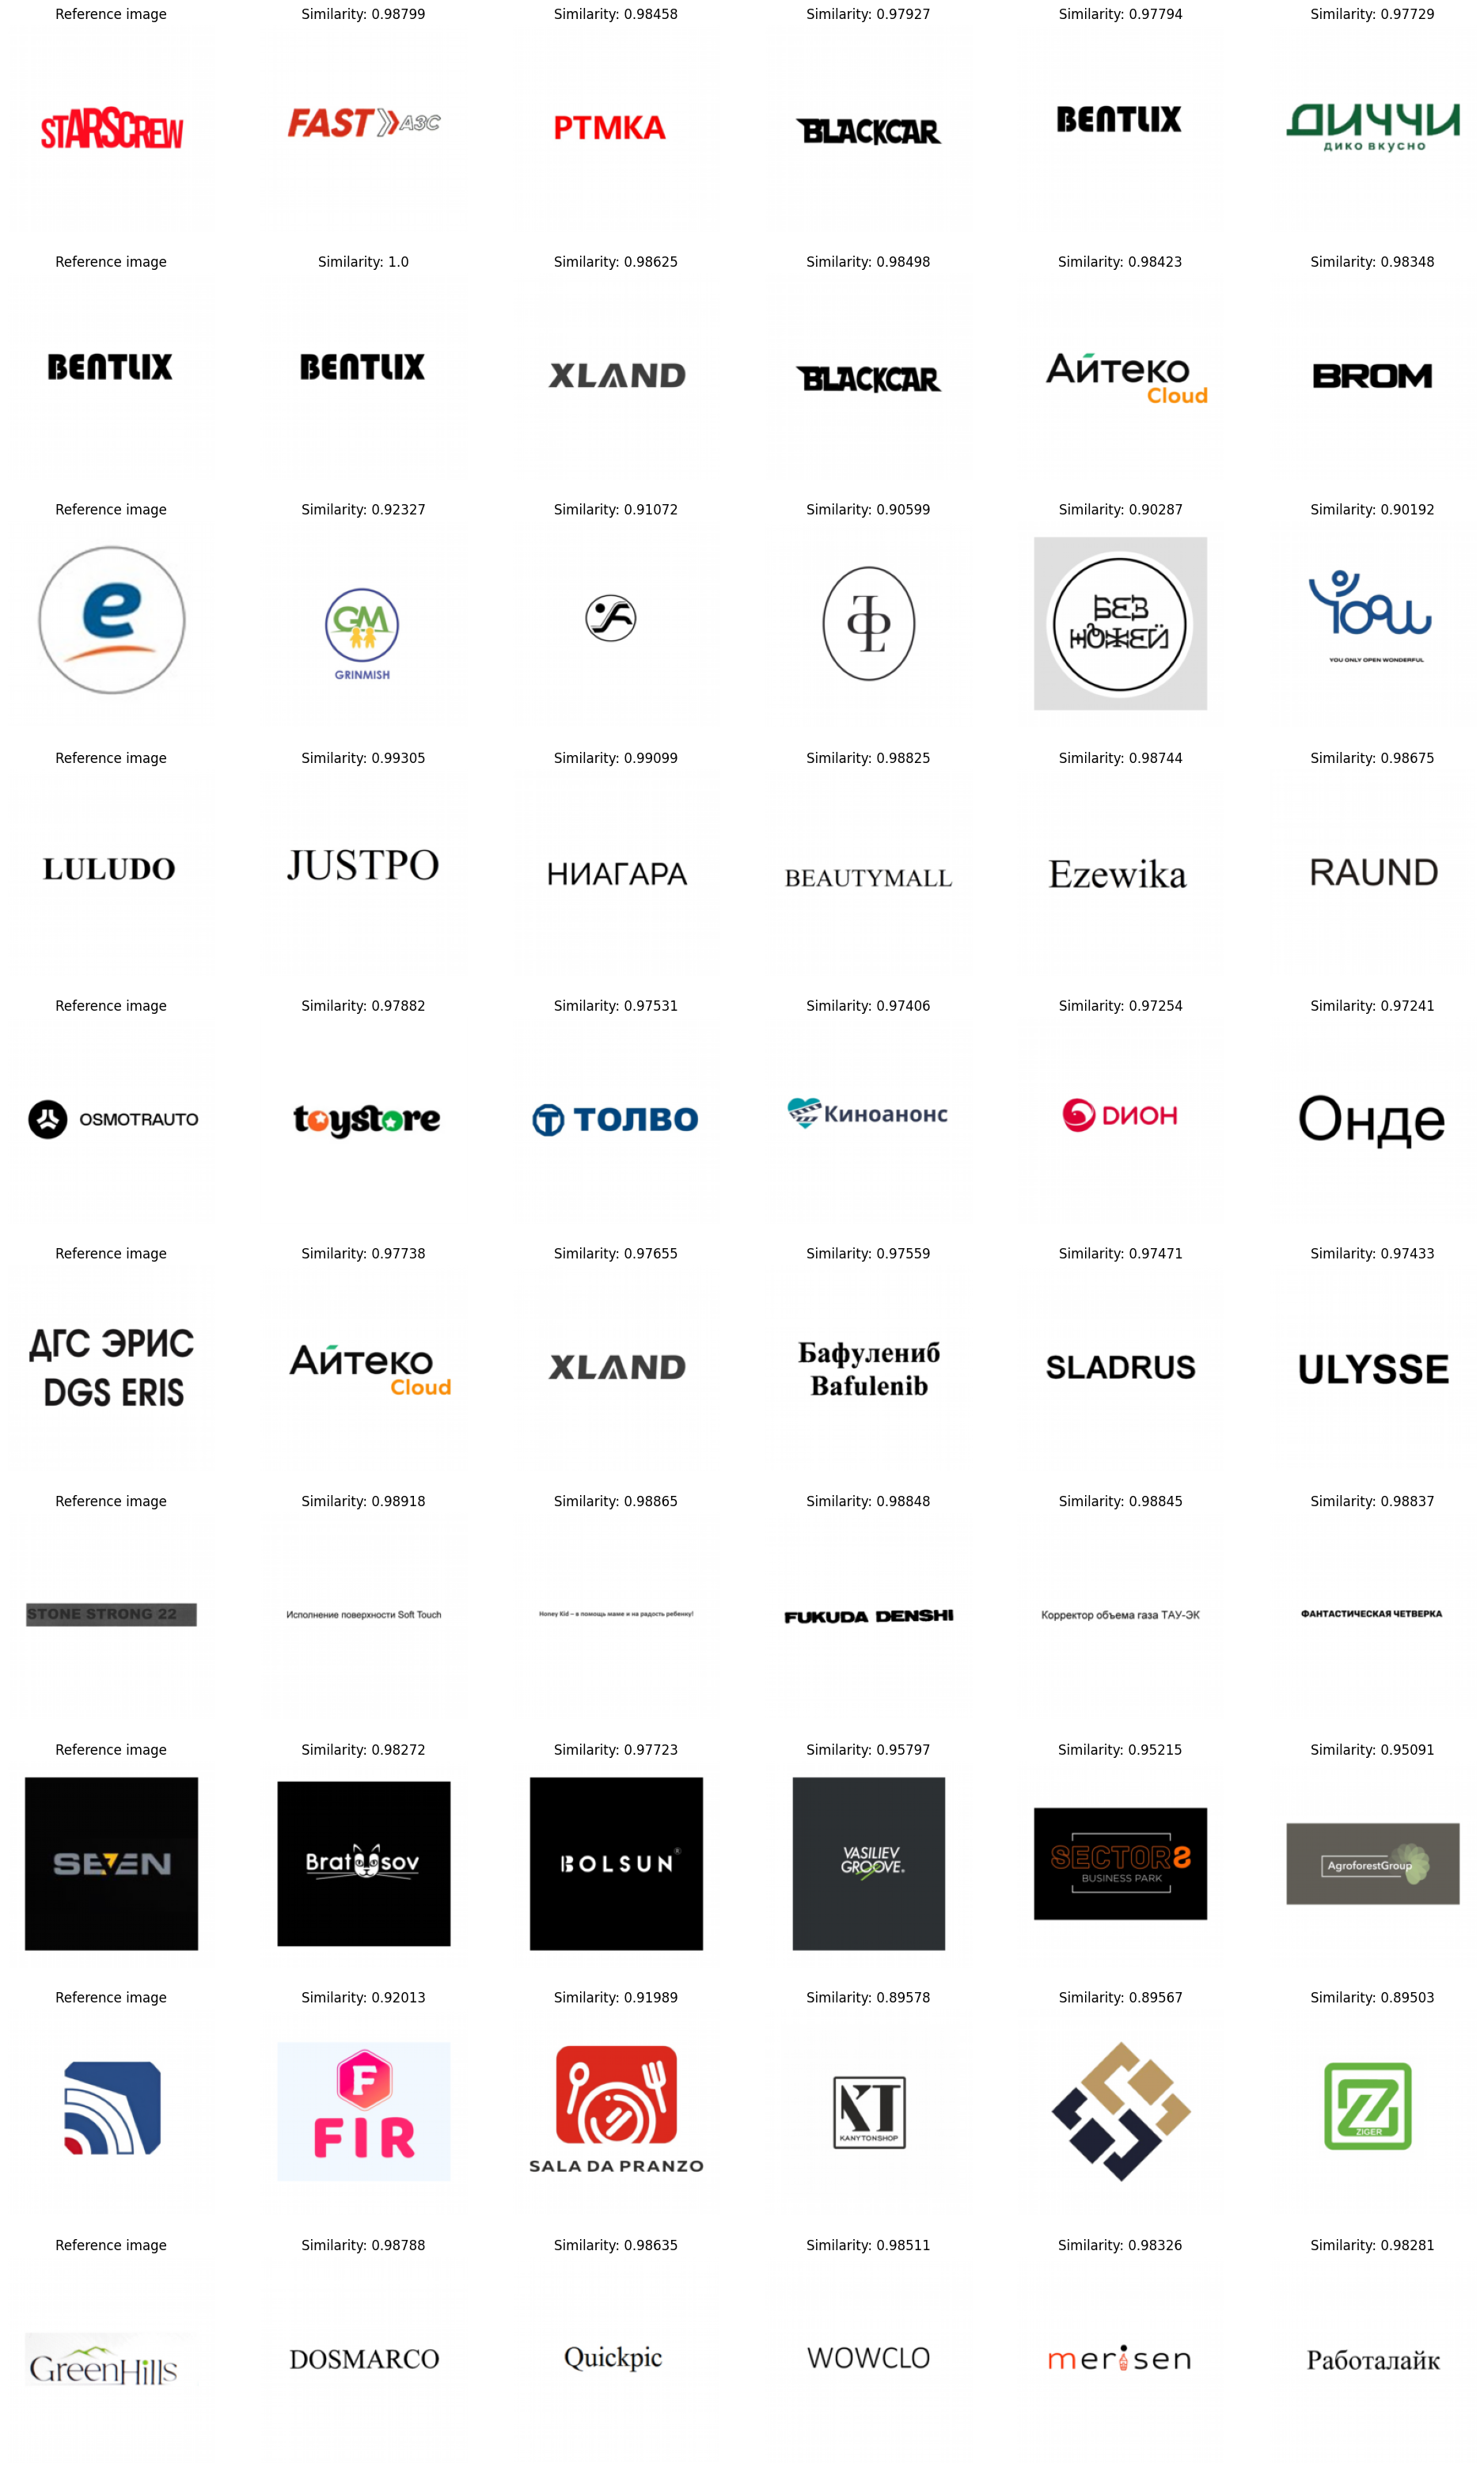

In [26]:
# Base model preview
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path)

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

similarity_fn = nn.CosineSimilarity()
model.eval()
for i, ax_row in tqdm(enumerate(axs)):
    img_path = image_paths[i]
    
    similarities = compute_similarity(img_path, image_embeddings, model).cpu().numpy().flatten()
    top_images = np.argsort(similarities)[::-1]

    for i, ax in enumerate(ax_row):
        if i == 0:
            img = load_image(img_path)
            ax.set_title('Reference image')
        else:
            idx = top_images[i - 1]
            img = load_image(image_embedding_paths[idx])
            similarity = similarities[idx]
            ax.set_title(f'Similarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()

In [27]:
detection_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
detection_model.classifier.append(nn.Linear(1000, 2)) # 2 classes: text, logo
detection_model.classifier.append(nn.Sigmoid())
load_model(detection_model, '../models/text_detect.safetensors')
detection_model = detection_model.to(device)
detection_model.eval()
detection_model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [28]:
classification, classification_path = generate_embeddings(detection_model)
classification

100%|██████████| 16/16 [00:04<00:00,  3.71it/s]


tensor([[1.2220e-09, 1.0000e+00],
        [7.3856e-13, 1.0000e+00],
        [9.6738e-01, 9.2161e-02],
        ...,
        [9.6176e-02, 9.5240e-01],
        [9.5261e-01, 1.0306e-01],
        [9.5309e-01, 1.2484e-01]], device='cuda:0')

In [29]:
logo_indices = []
for i in range(len(classification_path)):
    cl = classification[i]
    if cl[1] > 0.5: # 50% confidence of logo
        logo_indices.append(i)
logo_indices

[0,
 1,
 4,
 5,
 8,
 9,
 10,
 11,
 13,
 15,
 16,
 18,
 21,
 22,
 23,
 24,
 28,
 29,
 31,
 32,
 33,
 37,
 41,
 42,
 43,
 46,
 47,
 49,
 51,
 52,
 53,
 54,
 58,
 59,
 62,
 68,
 69,
 71,
 72,
 74,
 75,
 76,
 78,
 79,
 80,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 93,
 99,
 100,
 104,
 108,
 109,
 110,
 112,
 113,
 115,
 116,
 117,
 120,
 122,
 123,
 126,
 128,
 129,
 130,
 131,
 133,
 134,
 135,
 137,
 140,
 141,
 143,
 145,
 146,
 147,
 148,
 149,
 152,
 153,
 156,
 157,
 160,
 165,
 167,
 168,
 169,
 170,
 171,
 173,
 178,
 180,
 183,
 185,
 186,
 188,
 190,
 191,
 192,
 193,
 194,
 195,
 198,
 200,
 203,
 204,
 205,
 208,
 209,
 211,
 212,
 215,
 216,
 218,
 220,
 221,
 222,
 223,
 224,
 225,
 227,
 229,
 231,
 232,
 233,
 235,
 239,
 240,
 242,
 243,
 244,
 245,
 247,
 248,
 249,
 250,
 251,
 255,
 256,
 258,
 259,
 260,
 266,
 268,
 270,
 271,
 274,
 276,
 278,
 279,
 280,
 281,
 284,
 285,
 286,
 287,
 288,
 289,
 290,
 291,
 294,
 298,
 299,
 300,
 302,
 304,
 306,
 309,
 

In [30]:
def compute_similarity(image_path, embeddings, model):
    image = load_image(image_path)
    encoded = model.to(device)(image.unsqueeze(0).to(device)).detach()

    similarity_fn = nn.CosineSimilarity()
    def similarity(other_enc):
        return similarity_fn(encoded, other_enc)
    similarity_vec = torch.vmap(similarity)
    return similarity_vec(embeddings)


def evaluate_model_on(model, dataset_path, embeddings, embeddings_paths):
    # Load dataset
    sim_df = pd.read_csv(dataset_path, header=None, index_col=None)
    sim_df = [group.split(' ') for _, row in sim_df.items() for group in row]

    # Test for top-10 hits
    total_checks = 0
    misses = []
    for paths in tqdm(sim_df):
        for path_i, path_j in zip(paths, paths[1:]):
            path_i_real = os.path.join('../data/logos/', path_i)
            path_j_real = os.path.join('../data/logos/', path_j)

            # Test i->j
            similarities = compute_similarity(path_i_real, embeddings, model).cpu().numpy().flatten()
            top_images = np.argsort(similarities)[::-1]
            top_n = 10
            top_paths = [embeddings_paths[i] for i in top_images[:top_n]]
            total_checks += 1
            if os.path.join('../data/logos/', path_j) not in top_paths:
                misses.append((path_i_real, path_j_real))

            # Test j->i
            similarities = compute_similarity(path_j_real, embeddings, model).cpu().numpy().flatten()
            top_images = np.argsort(similarities)[::-1]
            top_n = 10
            top_paths = [embeddings_paths[i] for i in top_images[:top_n]]
            total_checks += 1
            if os.path.join('../data/logos/', path_i) not in top_paths:
                misses.append((path_j_real, path_i_real))

    print(f'Samples: {total_checks}, Misses: {len(misses)}')
    accuracy = 1.0 - len(misses) / total_checks
    print(f'^- Accuracy: {accuracy * 100.0:.2f}%')


def evaluate_model(model):
    print('Evaluating the model...')
    model.eval()

    print('1. Generating embeddings...')
    embeddings, embeddings_paths = generate_embeddings(model)

    print('2. Testing (validation part)...')
    evaluate_model_on(model, '../data/similar_valid.csv', embeddings, embeddings_paths)

    print('3. Testing (full dataset)...')
    evaluate_model_on(model, '../data/similar.csv', embeddings, embeddings_paths)

In [32]:
evaluate_model(model)

Evaluating the model...
1. Generating embeddings...


100%|██████████| 16/16 [00:04<00:00,  3.90it/s]


2. Testing (validation part)...


100%|██████████| 7/7 [00:00<00:00, 20.89it/s]


Samples: 16, Misses: 16
^- Accuracy: 0.00%
3. Testing (full dataset)...


100%|██████████| 36/36 [00:01<00:00, 33.32it/s]

Samples: 110, Misses: 109
^- Accuracy: 0.91%


cuda

Epoch 1/15


100%|██████████| 25/25 [00:00<00:00, 35.14it/s]



Epoch 2/15


100%|██████████| 25/25 [00:00<00:00, 41.40it/s]



Epoch 3/15


...

2. Testing (validation part)...


100%|██████████| 7/7 [00:00<00:00, 21.58it/s]


Samples: 16, Misses: 16
^- Accuracy: 0.00%
3. Testing (full dataset)...


100%|██████████| 36/36 [00:01<00:00, 32.46it/s]


Samples: 110, Misses: 109
^- Accuracy: 0.91%


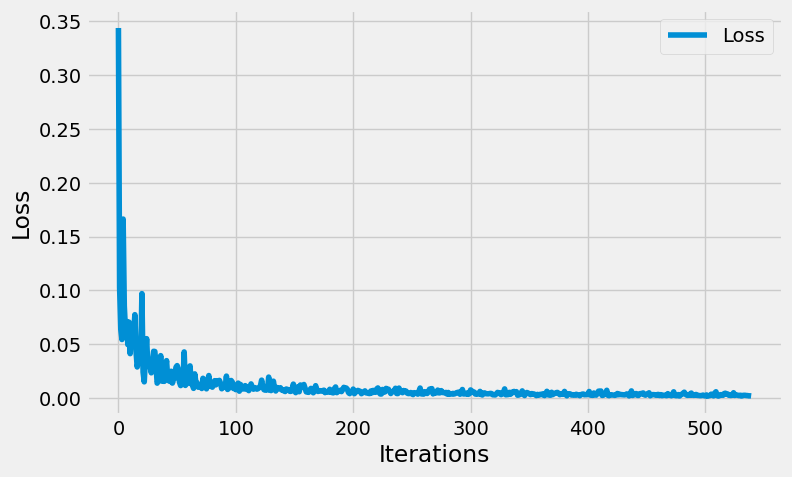

In [33]:
gc.collect()
torch.cuda.empty_cache()

loss_function = nn.CosineEmbeddingLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-8)

epochs = 15
losses = []

print(device)
model.to(device)

# Load dataset
train_df = pd.read_csv('../data/similar_train.csv', header=None, index_col=None)
train_df = [group.split(' ') for _, row in train_df.items() for group in row]

# Training
for epoch in range(epochs):
    print(f'\nEpoch {epoch + 1}/{epochs}')
    #if epoch % 5 == 0:
    #    evaluate_model(model)
    model.train()

    for paths in tqdm(train_df):
        for (path_i, path_j) in zip(paths, paths[1:]):
            # Train i - j
            path_i = os.path.join('../data/logos', path_i)
            path_j = os.path.join('../data/logos', path_j)
            images = torch.stack((load_image(path_i), load_image(path_j))).to(device)
            images = images.to(device)
            encoded = model(images)

            loss = loss_function(encoded[0], encoded[1], torch.tensor(1))
            losses.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        #break
    #break

print('Final evaluation:')
evaluate_model(model)

gc.collect()
torch.cuda.empty_cache()

model.eval()
save_model(model, '../models/similarity.safetensors')
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

10it [00:00, 25.75it/s]


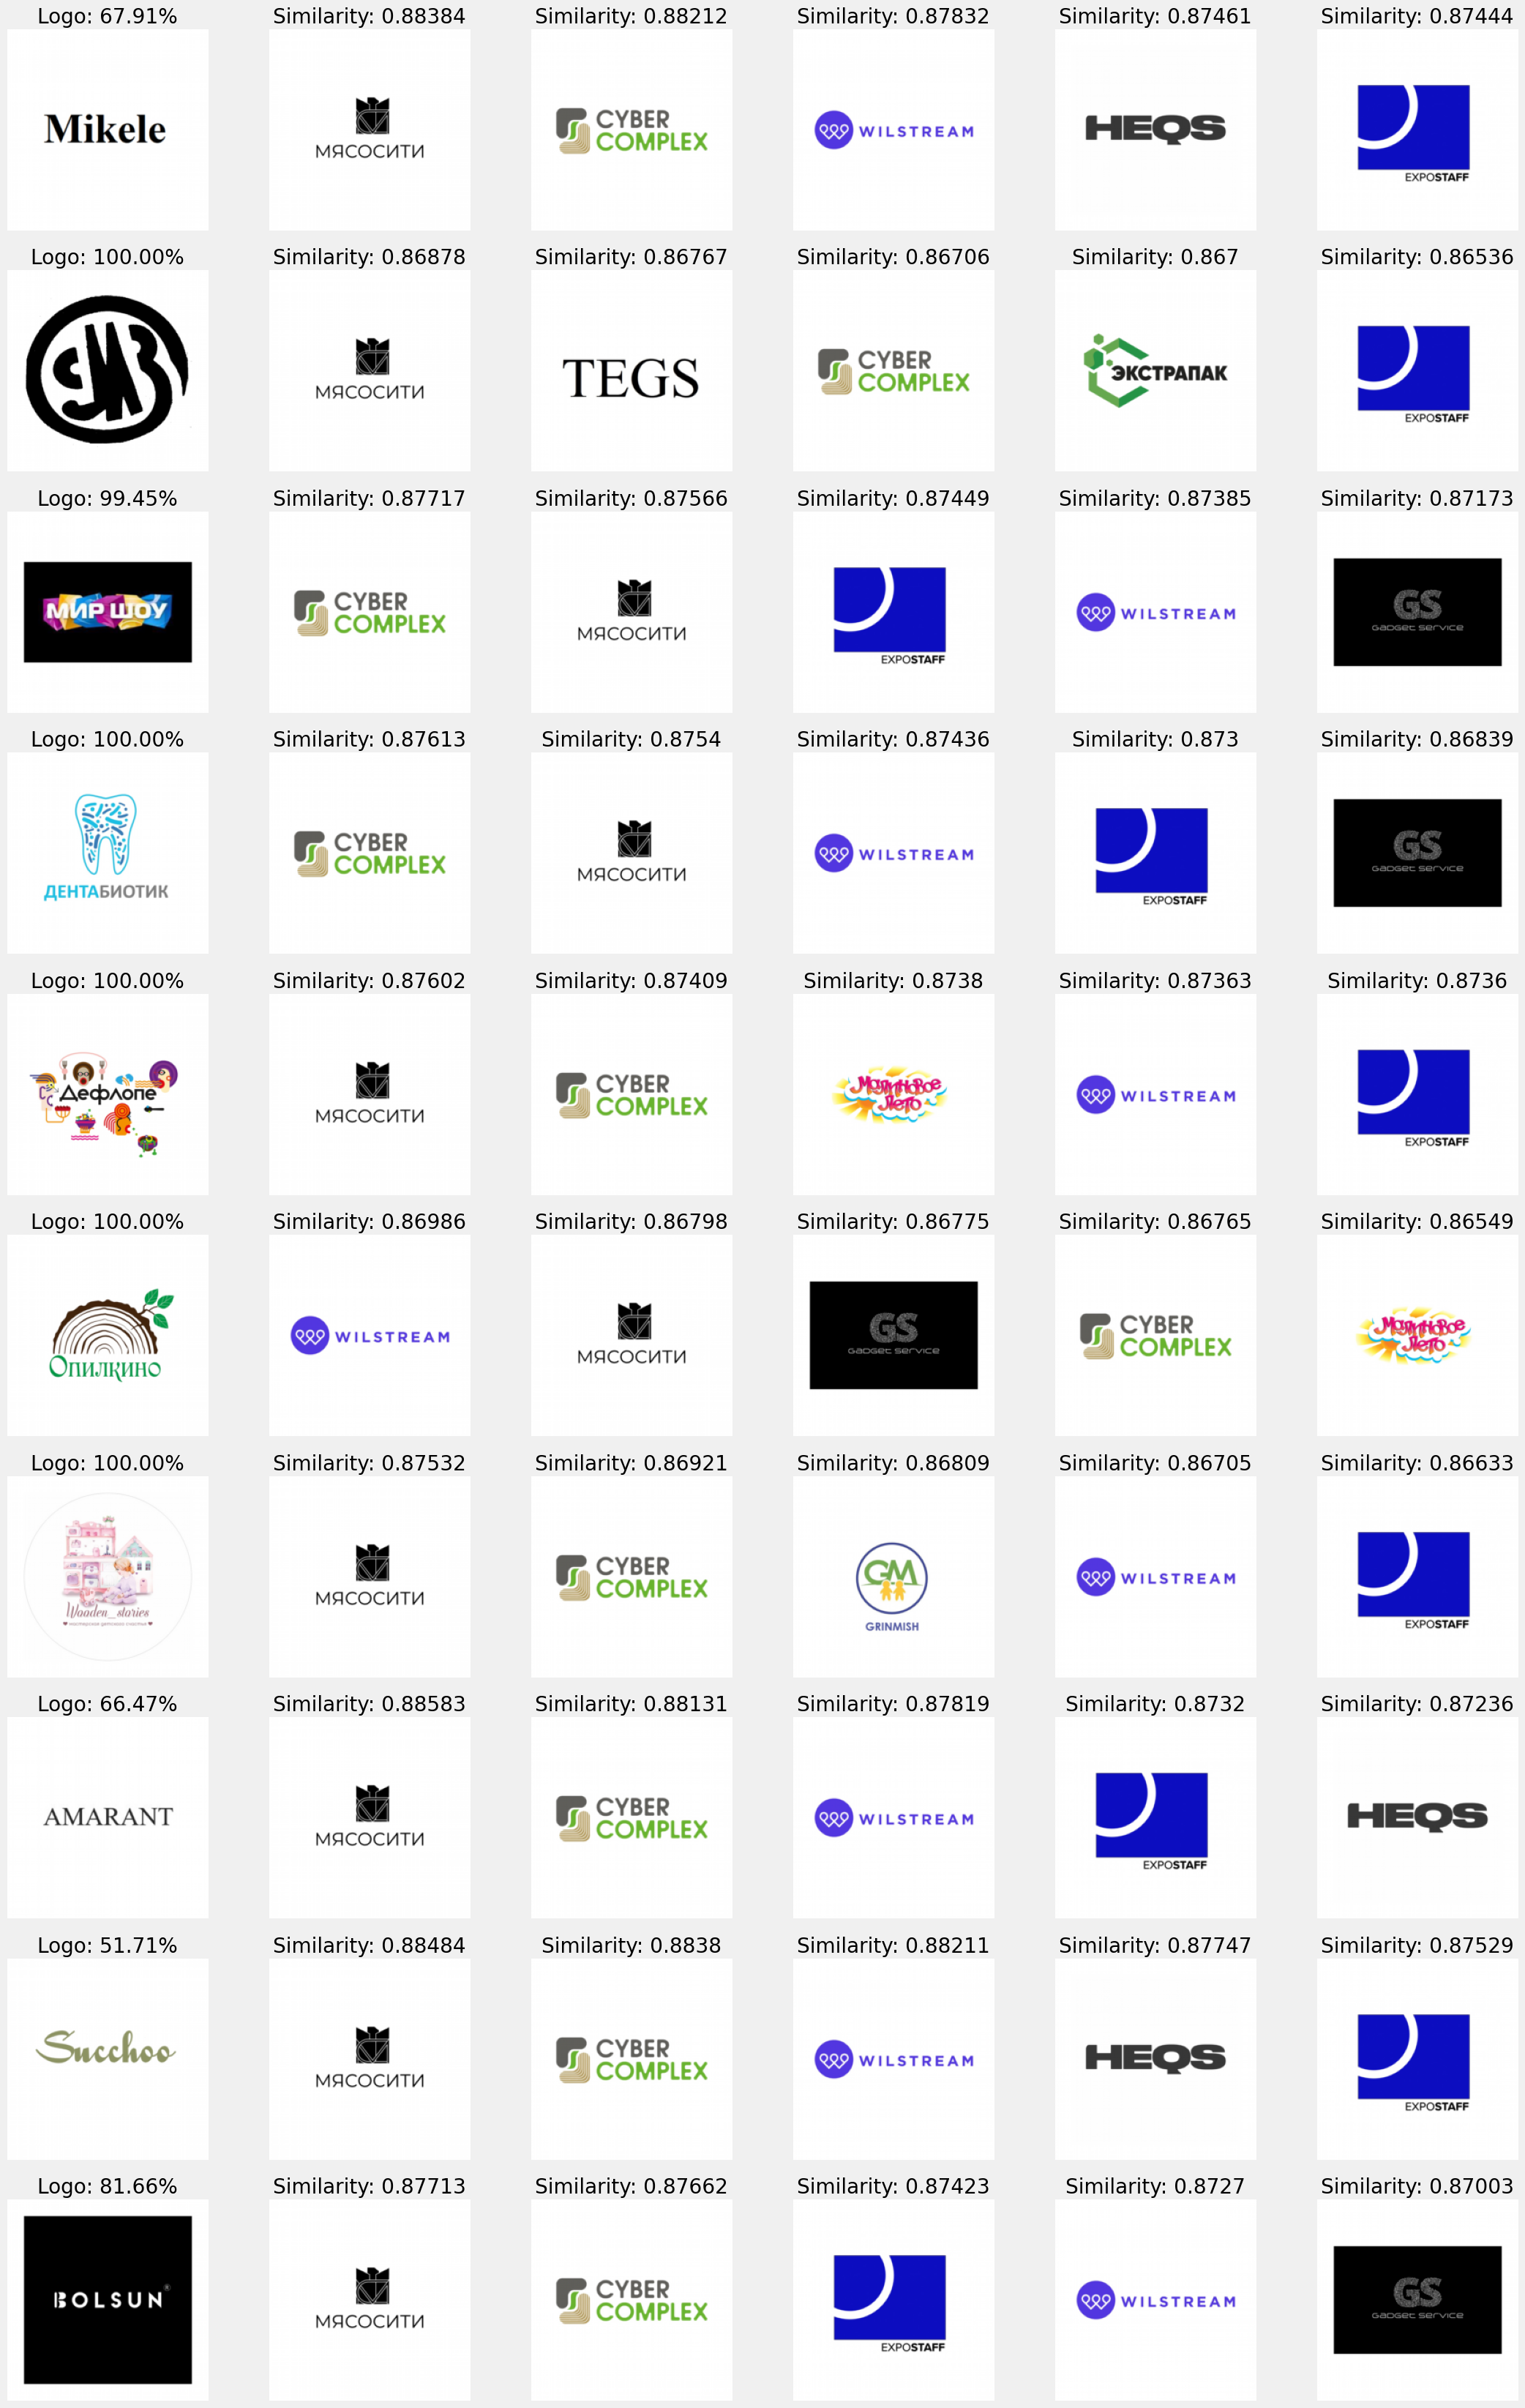

In [34]:
# Use the text-detection model to only check logos
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

np.random.shuffle(logo_indices)

for i, ax_row in tqdm(enumerate(axs)):
    img_index = logo_indices[i]
    img_path = classification_path[img_index]
    cl = classification[img_index]
    logo_confidence = cl[1].item() * 100

    similarities = compute_similarity(img_path, image_embeddings, model).cpu().numpy().flatten()
    top_images = np.argsort(similarities)[::-1]

    for i, ax in enumerate(ax_row):
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'Logo: {logo_confidence:.2f}%', )
        else:
            idx = top_images[i - 1]
            img = load_image(image_embedding_paths[idx])
            similarity = similarities[idx]
            ax.set_title(f'Similarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()

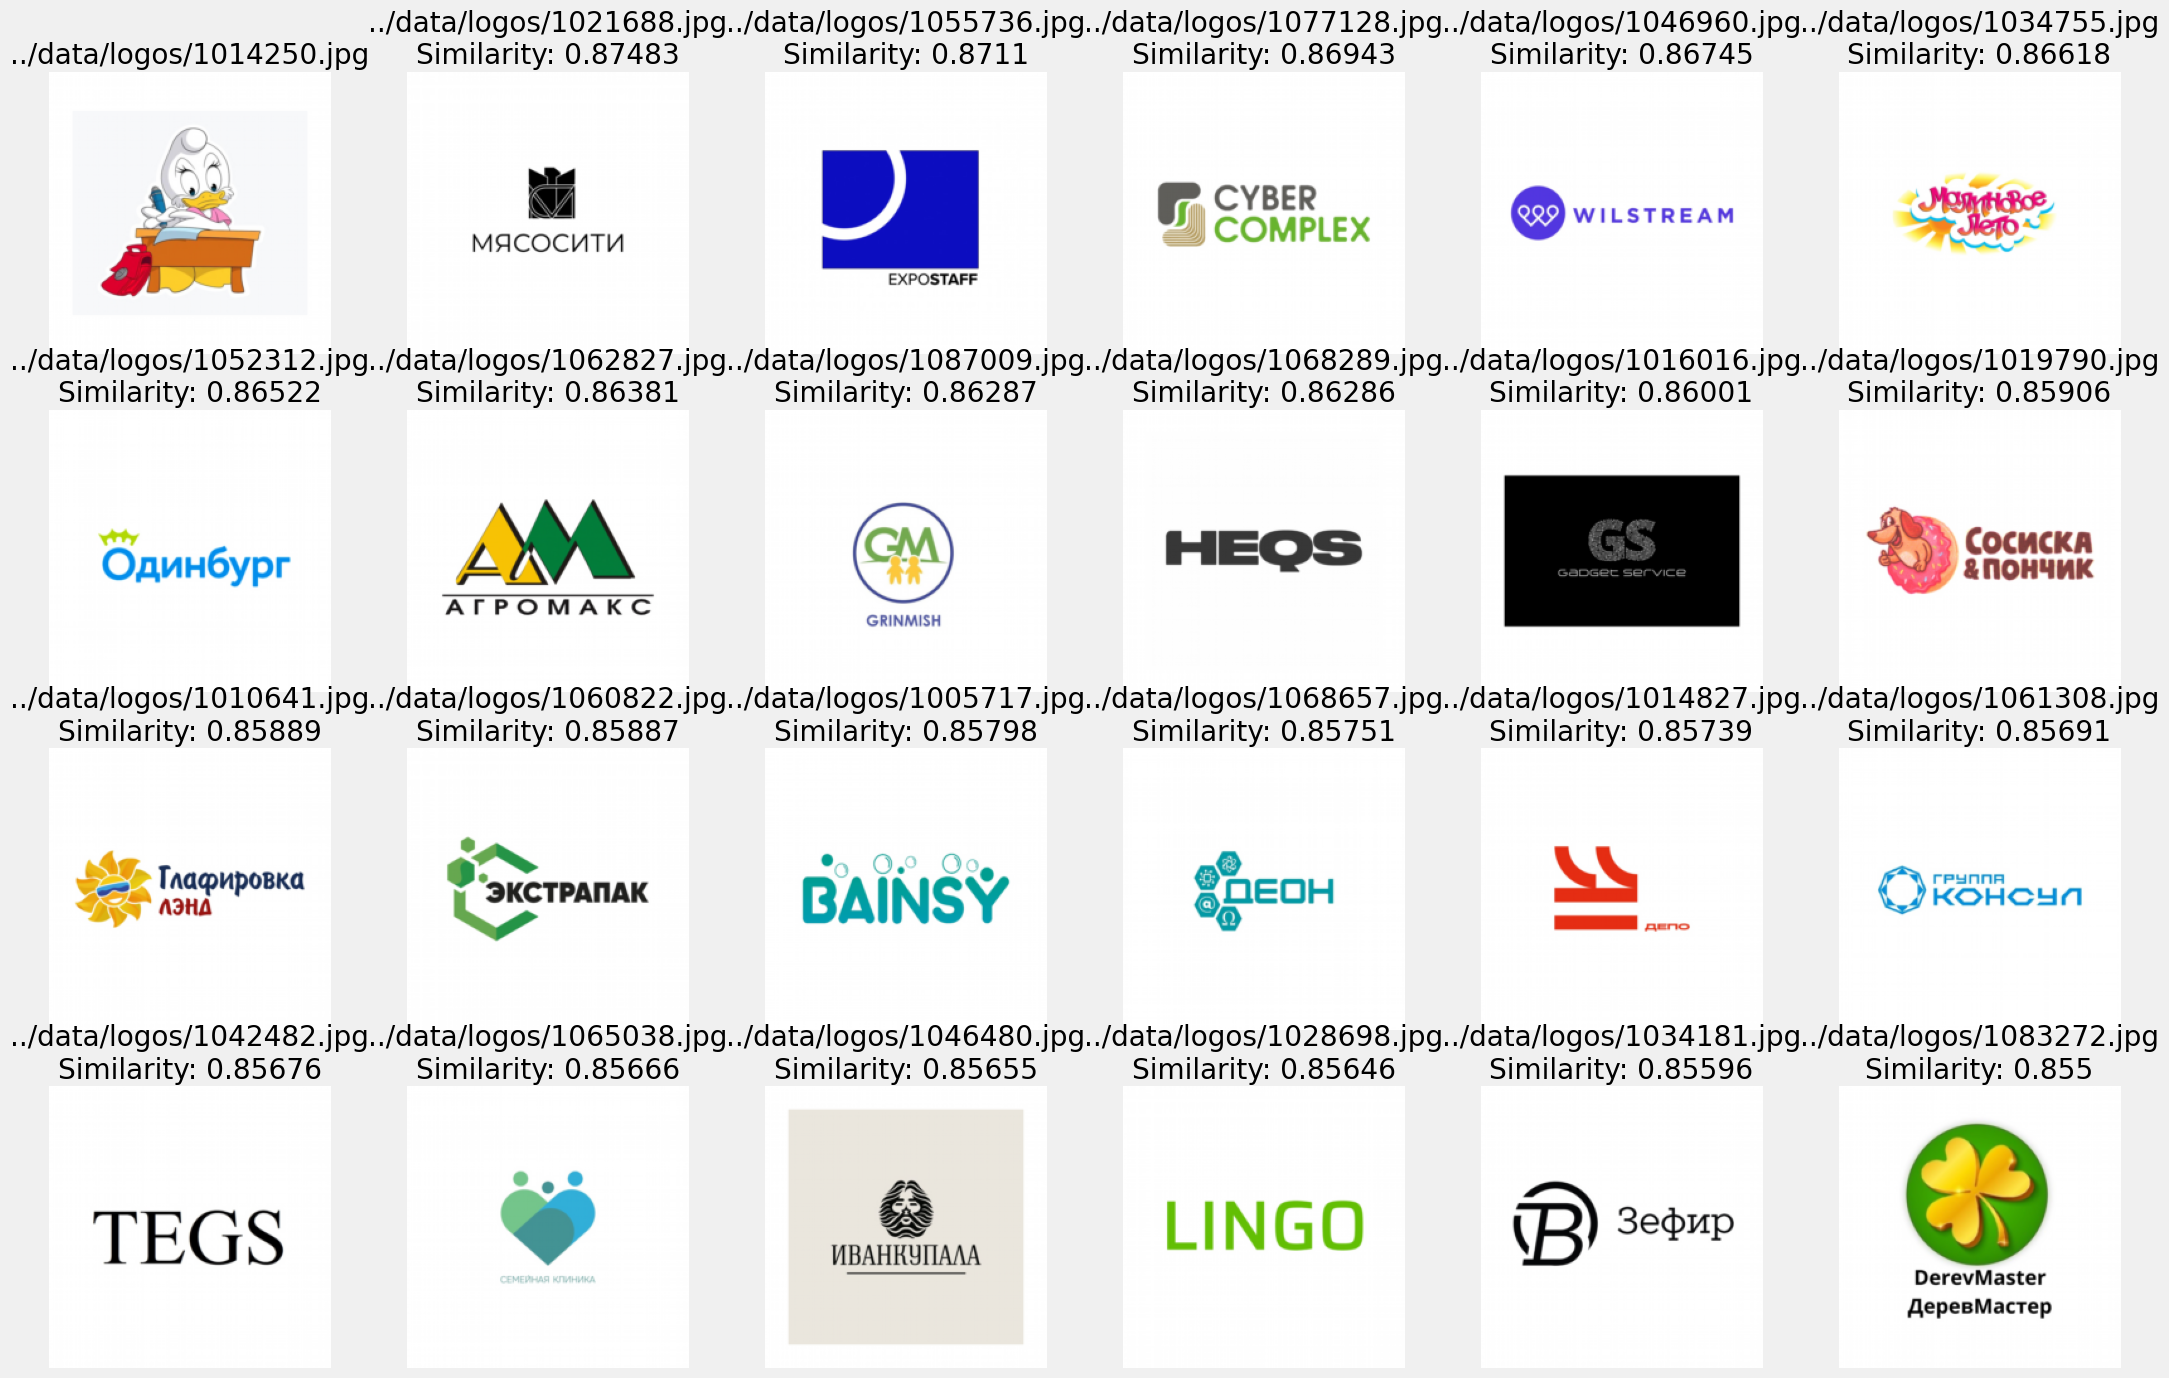

In [35]:
# Check a specific image
w, h = 6, 4
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

#img_path = '../data/logos/1074498.jpg' # bear
#img_path = '../data/logos/1018899.jpg' # dog булкин хвост
#img_path = '../data/logos/1007964.jpg' # fried chicken
#img_path = '../data/logos/1085495.jpg' # bipedal dog
#img_path = '../data/logos/1031647.jpg' # sitting bear?
img_path = '../data/logos/1014250.jpg' # 

similarities = compute_similarity(img_path, image_embeddings, model).cpu().numpy().flatten()
top_images = np.argsort(similarities)[::-1]

i = 0
for ax_row in axs:
    for ax in ax_row:
        if i == 0:
            img = load_image(img_path)
            ax.set_title(f'{img_path}')
        else:
            idx = top_images[i - 1]
            path = image_embedding_paths[idx]
            img = load_image(path)
            similarity = similarities[idx]
            ax.set_title(f'{path}\nSimilarity: {similarity:.5}')
        ax.set_axis_off()
        ax.imshow(img.transpose(0,1).transpose(1,2))
        i += 1

plt.show()

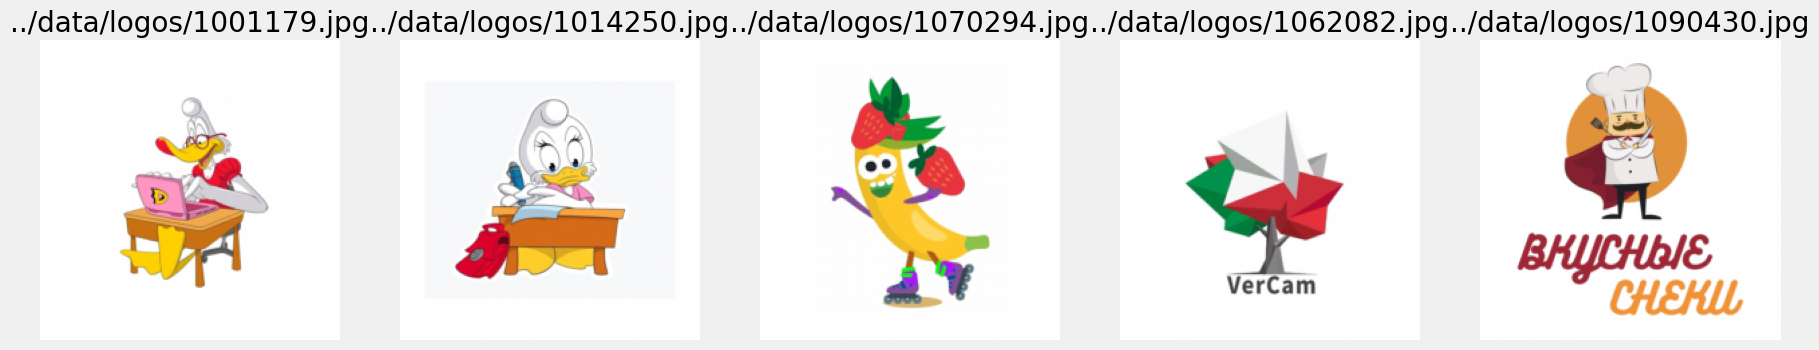

In [36]:
# Check a specific image
w, h = 5, 1
_, ax_row = plt.subplots(h, w, figsize=(w * 4, h * 4))

paths = [
    '../data/logos/1001179.jpg',
    '../data/logos/1014250.jpg',
    '../data/logos/1070294.jpg',
    '../data/logos/1062082.jpg',
    '../data/logos/1090430.jpg',
    '../data/logos/1077599.jpg',
    '../data/logos/1081661.jpg',
    '../data/logos/1068752.jpg',
    '../data/logos/1093562.jpg',
    '../data/logos/1012485.jpg',
]

for i, ax in enumerate(ax_row):
    path = paths[i]
    img = load_image(path)
    similarity = similarities[idx]
    ax.set_title(f'{path}')
    ax.set_axis_off()
    ax.imshow(img.transpose(0,1).transpose(1,2))

plt.show()